# Model Training Used Car Price Prediction

**Author:** Dinidu
**Scope:** Feature engineering integration, model comparison, hyperparameter
tuning, final model selection, and pipeline serialization.

This notebook follows the modeling approach agreed for the project:

1. Load and lightly clean the raw training data (deterministic parsing only —
   NO statistical imputation here, to avoid leakage).
2. Apply the 5 feature engineering techniques from `src/feature_engineering.py`.
3. Split 80/20 — the 20% is touched only ONCE, at the very end.
4. Build a `ColumnTransformer` where imputation/encoding/scaling are FIT
   only on the 80% training fold (fixes a leakage risk present in the
   original `src/data_preprocessing.py`, which computed medians on the
   full 6,019-row file before any split existed).
5. Compare Ridge, Random Forest, and Gradient Boosting via 5-fold CV on MAE.
6. Tune the best candidate(s) with `RandomizedSearchCV`.
7. Refit on the full 80% split, evaluate once on the held-out 20%.
8. Save the final pipeline as a single joblib artifact for FastAPI.

**Note on leakage fix:** `src/data_preprocessing.clean()` fills missing
numeric values using medians computed from the *entire* training file
before any train/test split exists. That's a data leakage risk once we
split 80/20, because the held-out 20% would have influenced its own
imputation values. This notebook therefore does NOT call the median-fill
step in `clean()` — instead it does only the deterministic, leakage-free
parts (unit extraction, invalid-value correction), and lets
`SimpleImputer` inside the `ColumnTransformer` learn medians ONLY from the
80% training fold, inside cross-validation. This will be flagged to
Kavindu so `data_preprocessing.py` can eventually be aligned, but it isn't
a blocker for this notebook.

In [2]:
import sys
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

1. Load raw data and apply deterministic (leakage-free) cleaning

This mirrors the deterministic parts of src/data_preprocessing.py (unit extraction, invalid-value correction) but deliberately skips its median-imputation step, for the leakage reason explained above.

In [3]:
DATASET_COLUMNS = [
    "record_id", "Name", "Location", "Year", "Kilometers_Driven",
    "Fuel_Type", "Transmission", "Owner_Type", "Mileage", "Engine",
    "Power", "Seats", "New_Price", "Price",
]
NUMERIC_COLUMNS = ["Year", "Kilometers_Driven", "Mileage", "Engine", "Power", "Seats", "New_Price"]
CATEGORICAL_COLUMNS = ["Location", "Fuel_Type", "Transmission", "Owner_Type"]


def _numeric_value(value):
    if pd.isna(value):
        return float("nan")
    text = str(value).replace(",", "")
    match = re.search(r"-?\d+(?:\.\d+)?", text)
    return float(match.group()) if match else float("nan")


def load_and_lightly_clean(path: Path) -> pd.DataFrame:
    """Deterministic parsing only — NO statistical imputation (leakage-free)."""
    frame = pd.read_csv(path)
    frame = frame.iloc[:, : len(DATASET_COLUMNS)].copy()
    frame.columns = DATASET_COLUMNS

    for column in NUMERIC_COLUMNS:
        frame[column] = frame[column].map(
            lambda v: (
                _numeric_value(v) * 100
                if column == "New_Price" and isinstance(v, str) and "cr" in v.lower()
                else _numeric_value(v)
            )
        )

    # Invalid measurements -> NaN (left for the pipeline's imputer to handle later)
    frame.loc[frame["Seats"] <= 0, "Seats"] = float("nan")
    frame.loc[frame["Mileage"] <= 0, "Mileage"] = float("nan")

    frame["Price"] = frame["Price"].map(_numeric_value)
    frame = frame.dropna(subset=["Price"])  # target must be present

    for column in CATEGORICAL_COLUMNS:
        frame[column] = frame[column].fillna("Unknown").astype("string")

    return frame


raw = load_and_lightly_clean(Path("/content/train-data.csv"))
print(f"Rows after dropping missing-target rows: {len(raw)}")
raw.head()

Rows after dropping missing-target rows: 6019


,record_id,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010.0,72000.0,CNG,Manual,First,26.60,998.0,58.16,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015.0,41000.0,Diesel,Manual,First,19.67,1582.0,126.20,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011.0,46000.0,Petrol,Manual,First,18.20,1199.0,88.70,5.0,8.61,4.50
3,3,Maruti Ertiga VDI,Chennai,2012.0,87000.0,Diesel,Manual,First,20.77,1248.0,88.76,7.0,NaN,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013.0,40670.0,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,NaN,17.74


2. Apply feature engineering (your tested module)

Uses add_features() from src/feature_engineering.py — the same function that will later be called by the FastAPI service, so training and inference feature logic can never drift apart.


In [4]:
engineered = add_features(raw)
print("New engineered columns:", ENGINEERED_FEATURE_COLUMNS)
engineered[["Year", "vehicle_age", "Kilometers_Driven", "mileage_per_year",
            "Power", "Engine", "power_per_cc", "Owner_Type", "owner_rank",
            "age_mileage_interaction"]].head()

New engineered columns: ['vehicle_age', 'mileage_per_year', 'power_per_cc', 'owner_rank', 'age_mileage_interaction']


,Year,vehicle_age,Kilometers_Driven,mileage_per_year,Power,Engine,power_per_cc,Owner_Type,owner_rank,age_mileage_interaction
0,2010.0,16.0,72000.0,4500.000000,58.16,998.0,0.058277,First,1,1152000.0
1,2015.0,11.0,41000.0,3727.272727,126.20,1582.0,0.079772,First,1,451000.0
2,2011.0,15.0,46000.0,3066.666667,88.70,1199.0,0.073978,First,1,690000.0
3,2012.0,14.0,87000.0,6214.285714,88.76,1248.0,0.071122,First,1,1218000.0
4,2013.0,13.0,40670.0,3128.461538,140.80,1968.0,0.071545,Second,2,528710.0


3. Train/test split — 80/20, held-out set touched only once

We split BEFORE any statistical fitting (imputation, encoding, scaling) happens, so nothing about the 20% held-out set can leak into training.

In [5]:
TARGET = "Price"

# New_Price is 86% missing and not used as a predictor at this stage —
# excluding it avoids an unreliable, mostly-imputed feature dominating
# the model. This is a deliberate, documented decision, not an oversight.
FEATURE_COLUMNS_NUMERIC = [
    "Kilometers_Driven", "Mileage", "Engine", "Power", "Seats",
    "vehicle_age", "mileage_per_year", "power_per_cc",
    "owner_rank", "age_mileage_interaction",
]
FEATURE_COLUMNS_CATEGORICAL = ["Location", "Fuel_Type", "Transmission"]
ALL_FEATURE_COLUMNS = FEATURE_COLUMNS_NUMERIC + FEATURE_COLUMNS_CATEGORICAL

X = engineered[ALL_FEATURE_COLUMNS]
y = engineered[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape}, Held-out test: {X_test.shape}")

Train: (4815, 13), Held-out test: (1204, 13)


4. Target transformation check

Price is heavily right-skewed (skew ≈ 3.34, verified earlier). We will train models on log1p(Price) and compare against raw Price at evaluation time — decision made empirically, not assumed.

In [6]:
print("Raw Price skew:", y_train.skew())
print("log1p(Price) skew:", np.log1p(y_train).skew())

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)  # only used for evaluating log-trained models, never for fitting

Raw Price skew: 3.4062254856654812
log1p(Price) skew: 0.7524380024987941


5. Preprocessing pipeline (ColumnTransformer)

    Numeric columns: median imputation, fit ONLY on X_train (fixes the leakage issue in data_preprocessing.py).
    Categorical columns: one-hot encoding with handle_unknown="ignore" (protects against unseen categories at inference time).
    Scaling: applied only inside the Ridge pipeline, not the tree models.


In [7]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_transformer, FEATURE_COLUMNS_NUMERIC),
    ("categorical", categorical_transformer, FEATURE_COLUMNS_CATEGORICAL),
])

# Ridge needs scaling after encoding; tree models don't.
preprocessor_scaled = ColumnTransformer(transformers=[
    ("numeric", Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), FEATURE_COLUMNS_NUMERIC),
    ("categorical", categorical_transformer, FEATURE_COLUMNS_CATEGORICAL),
])

6. Candidate models + 5-fold CV comparison

Three model families: linear baseline (Ridge), bagging ensemble (Random Forest), boosting ensemble (Gradient Boosting). Compared on cross-validated MAE, computed on the log1p(Price) target since that's expected to help the linear model most; RMSE/R² reported for context.


In [15]:
candidates = {
    "Ridge": Pipeline(steps=[
        ("preprocessor", preprocessor_scaled),
        ("model", Ridge(random_state=RANDOM_STATE)),
    ]),
    "RandomForest": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
    "GradientBoosting": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(random_state=RANDOM_STATE)),
    ]),
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

for name, pipeline in candidates.items():
    fold_mae = []
    for train_idx, val_idx in cv.split(X_train):
        X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_fold_train, y_fold_val = y_train_log.iloc[train_idx], y_train_log.iloc[val_idx]

        pipeline.fit(X_fold_train, y_fold_train)
        preds_log = pipeline.predict(X_fold_val)

        # Convert back to actual price scale before computing MAE,
        # since MAE in log-space isn't directly meaningful in Lakhs.
        preds = np.expm1(preds_log)
        actual = np.expm1(y_fold_val)
        fold_mae.append(mean_absolute_error(actual, preds))

    cv_results[name] = {
        "mean_mae": np.mean(fold_mae),
        "std_mae": np.std(fold_mae),
        "fold_mae": fold_mae,
    }
    print(f"{name}: mean CV-MAE = {np.mean(fold_mae):.3f} Lakh "
          f"(+/- {np.std(fold_mae):.3f})")

Ridge: mean CV-MAE = 2.401 Lakh (+/- 0.142)
RandomForest: mean CV-MAE = 1.571 Lakh (+/- 0.075)
GradientBoosting: mean CV-MAE = 1.788 Lakh (+/- 0.061)


7. Hyperparameter tuning on the best candidate(s)

RandomizedSearchCV over a modest, meaningful search space — not exhaustive grid search, to keep tuning time reasonable given the project timeline. Adjust param_distributions based on which model(s) performed best above.

In [10]:
import pandas as pd
from scipy.stats import randint, uniform

param_distributions = {
    "RandomForest": {
        "model__n_estimators": randint(100, 500),
        "model__max_depth": randint(5, 30),
        "model__min_samples_leaf": randint(1, 10),
    },
    "GradientBoosting": {
        "model__n_estimators": randint(100, 400),
        "model__learning_rate": uniform(0.01, 0.2),
        "model__max_depth": randint(2, 6),
    },
}

tuned_results = {}

for name, params in param_distributions.items():

    print(f"\n{'='*70}")
    print(f"Hyperparameter Tuning: {name}")
    print(f"{'='*70}")

    search = RandomizedSearchCV(
        candidates[name],
        param_distributions=params,
        n_iter=20,
        cv=cv,
        scoring="neg_mean_absolute_error",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        return_train_score=True,
    )

    search.fit(X_train, y_train_log)

    tuned_results[name] = search

    # Basic information
    print(f"Random combinations tested: {search.n_iter}")
    print(f"CV folds: {search.cv.get_n_splits()}")

    # Best result
    print(f"\nBest CV MAE (log-space): {-search.best_score_:.4f}")

    print("\nBest parameters:")
    for param, value in search.best_params_.items():
        print(f"  {param}: {value}")

    # Best estimator
    print("\nBest estimator:")
    print(search.best_estimator_)

    # Training vs validation
    best_index = search.best_index_

    train_mae = -search.cv_results_["mean_train_score"][best_index]
    validation_mae = -search.cv_results_["mean_test_score"][best_index]

    print(f"\nBest CV training MAE:   {train_mae:.4f}")
    print(f"Best CV validation MAE: {validation_mae:.4f}")

    # Top 5 configurations
    results_df = pd.DataFrame(search.cv_results_)

    top_results = results_df.sort_values(
        "rank_test_score"
    ).head(5).copy()

    top_results["CV_MAE"] = -top_results["mean_test_score"]

    print("\nTop 5 parameter combinations:")
    print(
        top_results[
            [
                "rank_test_score",
                "CV_MAE",
                "std_test_score",
                "params",
            ]
        ].to_string(index=False)
    )


Hyperparameter Tuning: RandomForest
Random combinations tested: 20
CV folds: 5

Best CV MAE (log-space): 0.1333

Best parameters:
  model__max_depth: 29
  model__min_samples_leaf: 2
  model__n_estimators: 364

Best estimator:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Kilometers_Driven',
                                                   'Mileage', 'Engine', 'Power',
                                                   'Seats', 'vehicle_age',
                                                   'mileage_per_year',
                                                   'power_per_cc', 'owner_rank',
                                                   'age_mileage_interaction']),
                                     

8. Final model selection

Selection criterion (stated explicitly, per project rubric): lowest cross-validated MAE on the actual price scale, with RMSE and R² as supporting evidence — not selected on R² alone.

Pick the best-performing tuned model based on the printed results above, then refit it on the FULL 80% training set and evaluate ONCE on the held-out 20% test set.


In [11]:
# Select the best model based on cross-validation
BEST_MODEL_NAME = "GradientBoosting"

final_pipeline = tuned_results[BEST_MODEL_NAME].best_estimator_

# Predict on the untouched 20% held-out test set
test_preds_log = final_pipeline.predict(X_test)

# Convert predictions back from log-space to original price scale
test_preds = np.expm1(test_preds_log)

# Final evaluation on original price values (Lakh)
final_mae = mean_absolute_error(y_test, test_preds)
final_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
final_r2 = r2_score(y_test, test_preds)

print(f"FINAL HELD-OUT TEST RESULTS ({BEST_MODEL_NAME}):")
print(f"  MAE:  {final_mae:.3f} Lakh")
print(f"  RMSE: {final_rmse:.3f} Lakh")
print(f"  R²:   {final_r2:.4f}")

FINAL HELD-OUT TEST RESULTS (GradientBoosting):
  MAE:  1.405 Lakh
  RMSE: 3.474 Lakh
  R²:   0.9019


ERROR DISTRIBUTION SUMMARY
count    1204.000000
mean        1.405287
std         3.178067
min         0.000343
25%         0.218088
50%         0.523808
75%         1.318004
max        64.720127
Name: abs_error, dtype: float64

TOP 10 WORST PREDICTIONS (by absolute error)
      actual_price  predicted_price      error    pct_error  vehicle_age  Kilometers_Driven  Power  Engine Fuel_Type Transmission
3132          2.02        66.740127  64.720127  3203.966704          7.0            14298.0  340.0  2995.0    Petrol    Automatic
926          40.00        10.977899 -29.022101   -72.555252         16.0            10000.0    NaN  3436.0    Petrol       Manual
5075         29.00         7.077315 -21.922685   -75.595465         19.0            43627.0  186.0  1796.0    Petrol    Automatic
5341         67.83        46.388979 -21.441021   -31.609938         10.0            65003.0  382.0  4134.0    Diesel    Automatic
2306         40.00        19.206729 -20.793271   -51.983178         16.0     

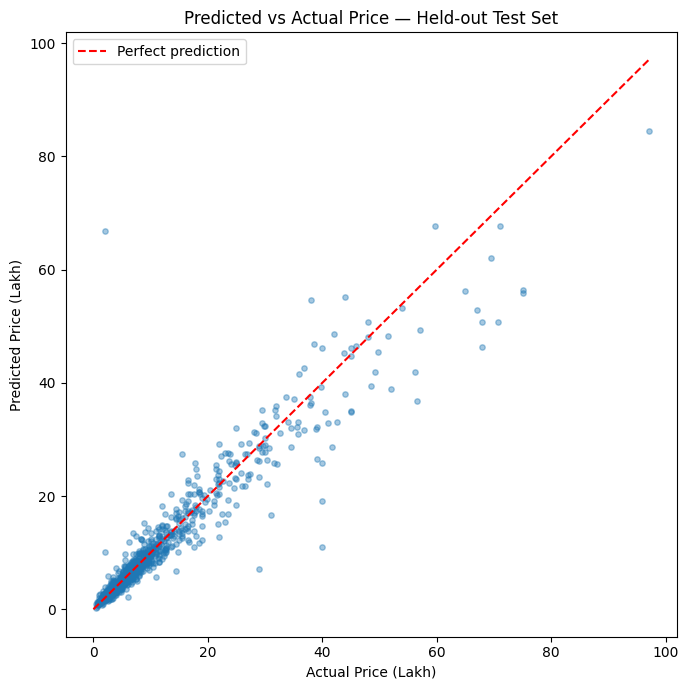

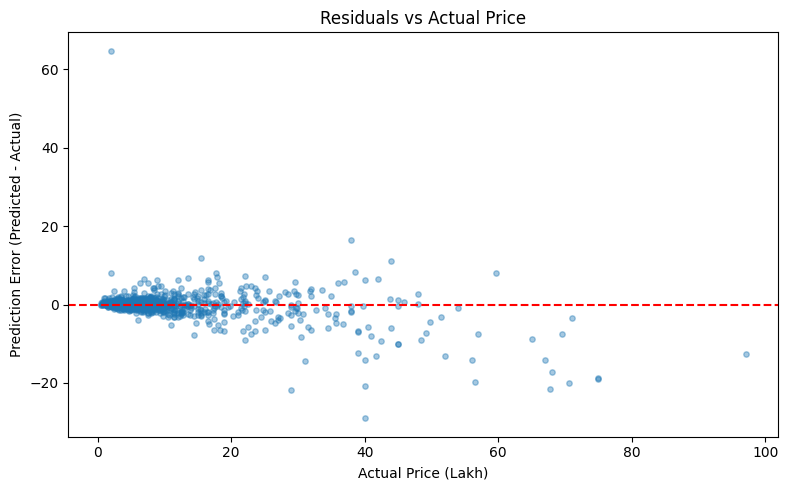

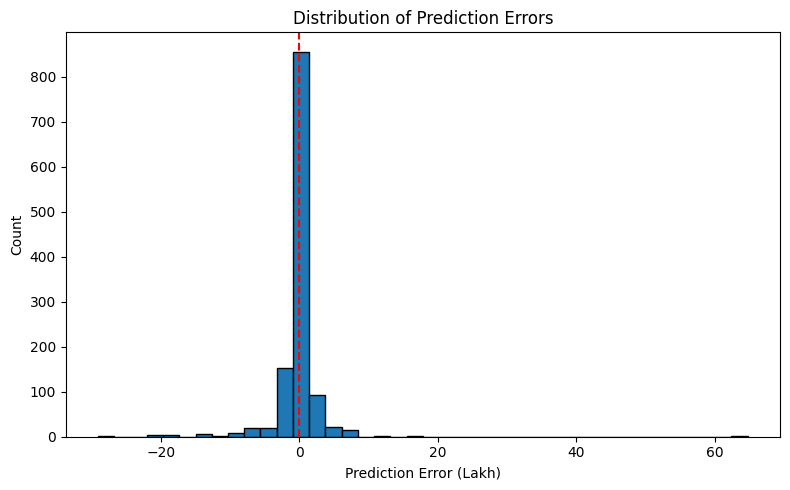


MAE BY PRICE BAND (does error grow for expensive cars?)
                 mean  count
price_band                  
0-5L         0.543564    541
5-10L        0.867999    369
10-20L       2.090992    159
20-50L       4.540468    118
50L+        12.315459     17


In [12]:
import matplotlib.pyplot as plt

# Build a results dataframe aligned with the held-out test set for inspection.
results_df = X_test.copy()
results_df["actual_price"] = y_test.values
results_df["predicted_price"] = test_preds
results_df["error"] = results_df["predicted_price"] - results_df["actual_price"]
results_df["abs_error"] = results_df["error"].abs()
results_df["pct_error"] = (results_df["error"] / results_df["actual_price"]) * 100

print("=" * 70)
print("ERROR DISTRIBUTION SUMMARY")
print("=" * 70)
print(results_df["abs_error"].describe())

print("\n" + "=" * 70)
print("TOP 10 WORST PREDICTIONS (by absolute error)")
print("=" * 70)
worst = results_df.sort_values("abs_error", ascending=False).head(10)
print(worst[["actual_price", "predicted_price", "error", "pct_error",
             "vehicle_age", "Kilometers_Driven", "Power", "Engine",
             "Fuel_Type", "Transmission"]].to_string())

print("\n" + "=" * 70)
print("BEST 10 PREDICTIONS (by absolute error)")
print("=" * 70)
best = results_df.sort_values("abs_error", ascending=True).head(10)
print(best[["actual_price", "predicted_price", "error", "pct_error"]].to_string())

# --- Plot 1: Predicted vs Actual ---
plt.figure(figsize=(7, 7))
plt.scatter(results_df["actual_price"], results_df["predicted_price"], alpha=0.4, s=15)
max_val = max(results_df["actual_price"].max(), results_df["predicted_price"].max())
plt.plot([0, max_val], [0, max_val], "r--", label="Perfect prediction")
plt.xlabel("Actual Price (Lakh)")
plt.ylabel("Predicted Price (Lakh)")
plt.title("Predicted vs Actual Price — Held-out Test Set")
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot 2: Residuals vs Actual Price (spot heteroscedasticity) ---
plt.figure(figsize=(8, 5))
plt.scatter(results_df["actual_price"], results_df["error"], alpha=0.4, s=15)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Actual Price (Lakh)")
plt.ylabel("Prediction Error (Predicted - Actual)")
plt.title("Residuals vs Actual Price")
plt.tight_layout()
plt.show()

# --- Plot 3: Error distribution histogram ---
plt.figure(figsize=(8, 5))
plt.hist(results_df["error"], bins=40, edgecolor="black")
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Prediction Error (Lakh)")
plt.ylabel("Count")
plt.title("Distribution of Prediction Errors")
plt.tight_layout()
plt.show()

# --- Check: does error correlate with price band? ---
results_df["price_band"] = pd.cut(
    results_df["actual_price"],
    bins=[0, 5, 10, 20, 50, results_df["actual_price"].max()],
    labels=["0-5L", "5-10L", "10-20L", "20-50L", "50L+"],
)
print("\n" + "=" * 70)
print("MAE BY PRICE BAND (does error grow for expensive cars?)")
print("=" * 70)
print(results_df.groupby("price_band", observed=True)["abs_error"].agg(["mean", "count"]))

9. Save the final pipeline

Single joblib artifact containing the full preprocessing (imputer, encoder) + trained model, ready for FastAPI to load and call directly on raw feature-engineered input. Note the API must still call add_features() before passing data into this pipeline, since feature engineering happens BEFORE the ColumnTransformer, not inside it.


In [17]:
import joblib
MODELS_DIR = Path("/content/models")
MODELS_DIR.mkdir(exist_ok=True)

joblib.dump(final_pipeline, MODELS_DIR / "final_pipeline.joblib")

metadata = {
    "model_name": BEST_MODEL_NAME,
    "target_transform": "log1p",
    "feature_columns_numeric": FEATURE_COLUMNS_NUMERIC,
    "feature_columns_categorical": FEATURE_COLUMNS_CATEGORICAL,
    "held_out_test_mae": final_mae,
    "held_out_test_rmse": final_rmse,
    "held_out_test_r2": final_r2,
    "best_params": tuned_results[BEST_MODEL_NAME].best_params_,
}
with open(MODELS_DIR / "model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved final_pipeline.joblib and model_metadata.json")

Saved final_pipeline.joblib and model_metadata.json
